In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv("/Users/jana/Documents/Github/Data_Mining_Project/dataset/processed/image_features.csv")
df = df.drop(columns=["error"])

feature_cols_model = [
    "aspect_ratio",
    "mean_r", "mean_g", "mean_b",
    "std_r", "std_g", "std_b",
    "brightness", "contrast", "entropy",
    "sharpness", "edge_density", "colorfulness"
]

X = df[feature_cols_model].copy()
y = (df["label"] == "fake").astype(int)

train_mask = df["split"] == "train"
test_mask = df["split"] == "test"

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6393333333333333
ROC-AUC: 0.6925549722222222

Confusion Matrix:
 [[4092 1908]
 [2420 3580]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.68      0.65      6000
           1       0.65      0.60      0.62      6000

    accuracy                           0.64     12000
   macro avg       0.64      0.64      0.64     12000
weighted avg       0.64      0.64      0.64     12000



### Coefficient Table

In [6]:
coef_df = pd.DataFrame({
    "feature": feature_cols_model,
    "coefficient": clf.coef_[0]
}).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

coef_df

,feature,coefficient
8,contrast,-3.033590
5,std_g,2.915298
2,mean_g,-0.712473
4,std_r,0.681663
3,mean_b,0.527348
1,mean_r,0.343268
6,std_b,-0.264534
11,edge_density,0.223162
7,brightness,-0.216243
10,sharpness,0.140045


### Coefficient plot

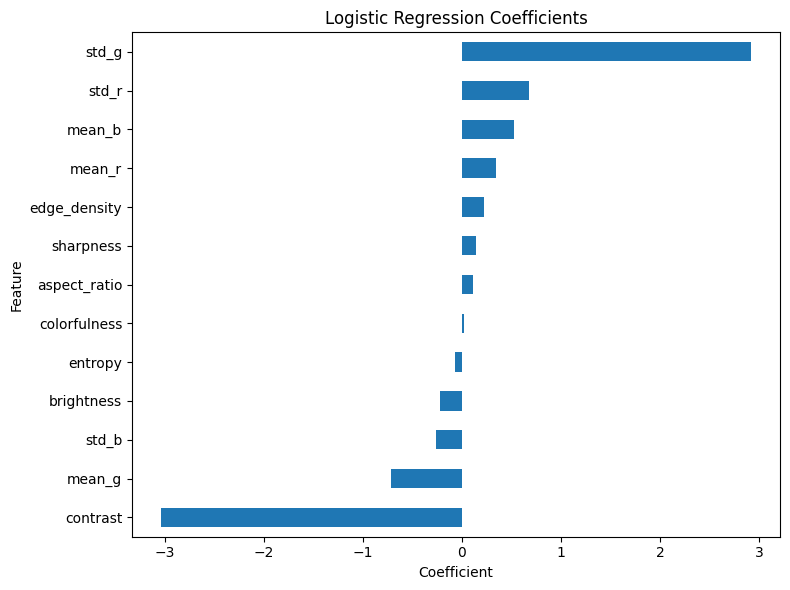

In [7]:
coef_df.sort_values("coefficient").plot(
    x="feature", y="coefficient", kind="barh", figsize=(8, 6), legend=False
)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Result Analysis

Simple visual statistics capture meaningful differences between real and AI-generated images, but those differences are only partially separable.

- positive coefficient pushes prediction toward fake
- negative coefficient pushes prediction toward real

More associated with fake
- std_g
- std_r
- mean_b
- mean_r
- edge_density
- sharpness

More associated with real
- contrast
- mean_g
- brightness
- std_b

The biggest effects are:

- `contrast` strongly toward real
- `std_g` strongly toward fake

AI-generated and real images show measurable differences in interpretable visual features, and those differences are visible in feature space and moderately predictive in a simple model.

### ROC curve

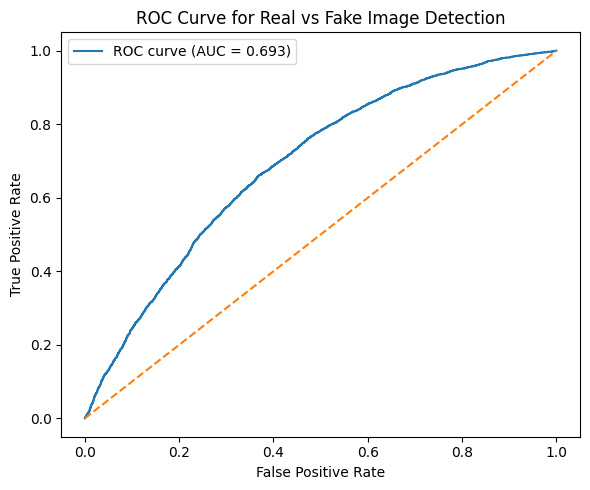

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Real vs Fake Image Detection")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold comparison

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

for thresh in [0.3, 0.5, 0.7]:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    
    threshold_results.append({
        "threshold": thresh,
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "precision": precision_score(y_test, y_pred_thresh),
        "recall": recall_score(y_test, y_pred_thresh),
        "f1": f1_score(y_test, y_pred_thresh)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,accuracy,precision,recall,f1
0,0.3,0.548750,0.526231,0.978000,0.684275
1,0.5,0.639333,0.652332,0.596667,0.623259
2,0.7,0.543417,0.721325,0.141500,0.236589


### Error analysis table

In [21]:
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)
test_df["y_true"] = y_test.reset_index(drop=True)
test_df["y_prob_fake"] = y_prob
test_df["y_pred"] = y_pred

test_df["error_type"] = "correct"
test_df.loc[(test_df["y_true"] == 1) & (test_df["y_pred"] == 0), "error_type"] = "false_negative"
test_df.loc[(test_df["y_true"] == 0) & (test_df["y_pred"] == 1), "error_type"] = "false_positive"

test_df["error_type"].value_counts()

error_type
correct           7672
false_negative    2420
false_positive    1908
Name: count, dtype: int64

In [22]:
error_feature_summary = test_df.groupby("error_type")[feature_cols_model].mean().T
error_feature_summary

error_type,correct,false_negative,false_positive
aspect_ratio,1.078377,1.021940,1.140468
mean_r,114.579783,115.566706,113.820042
mean_g,108.782146,111.259744,103.034073
mean_b,101.339182,102.980331,93.872029
std_r,57.600704,52.968092,62.643479
std_g,53.751159,50.043393,59.288117
std_b,52.736191,50.508693,55.110972
brightness,109.665705,111.605089,105.212749
contrast,53.047637,49.949198,57.705170
entropy,6.820206,6.796978,7.083892


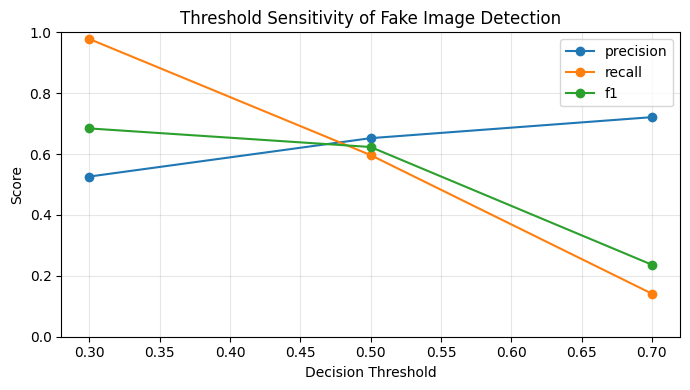

In [26]:
threshold_df.plot(x="threshold", y=["precision", "recall", "f1"], marker="o", figsize=(7, 4))
plt.title("Threshold Sensitivity of Fake Image Detection")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Error-type comparison bar chart

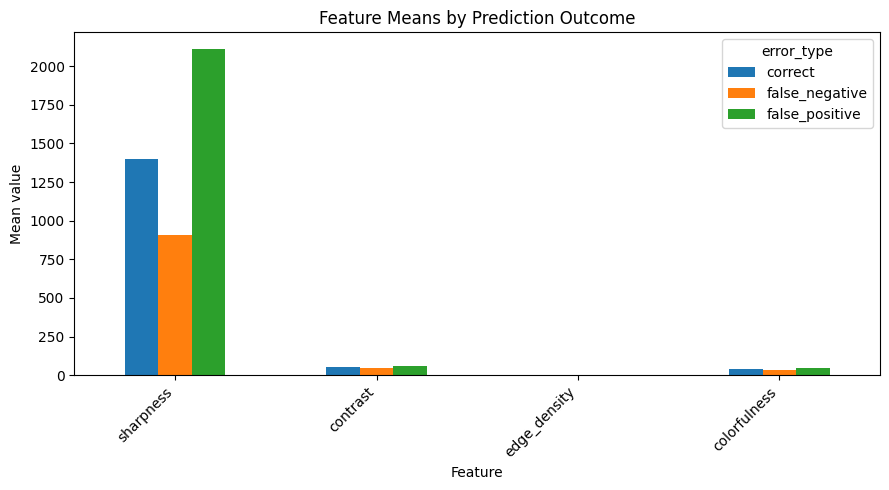

In [27]:
top_error_features = ["sharpness", "contrast", "edge_density", "colorfulness"]

error_summary = test_df.groupby("error_type")[top_error_features].mean().T
error_summary.plot(kind="bar", figsize=(9, 5))
plt.title("Feature Means by Prediction Outcome")
plt.xlabel("Feature")
plt.ylabel("Mean value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

AUC ≈ 0.693
simple handcrafted features contain signal, but not enough for highly reliable detection.

#### Threshold sensitivity

- at 0.3, recall is extremely high (0.978) but precision is low (0.526)
- at 0.5, performance is more balanced
- at 0.7, precision rises (0.721) but recall collapses (0.142)

the model can be tuned either to catch most fake images or to avoid false alarms, but it cannot do both well at the same time.

#### Error analysis

False positives:
Real images predicted as fake tend to be:

- much sharper
- higher contrast
- higher edge density
- more colorful

False negatives:
Fake images predicted as real tend to be:

- less sharp
- lower contrast
- lower edge density
- less colorful

the model mistakes visually intense real images for fake, and misses fake images that look softer and more natural.